# Problem 2: Plotting Data

In Problem #1 we implemented code that generates a CVS file of hourly Ticker data for past 5 days for Stocks META, AAPL, AMZN, NFLX, GOOG   
We now need to plot the Close price data for each of these five stocks

## Reading wide format CSV with multi-level columns 
I had struggles with reading this CSV format where multiple stock's data is spread across multiple columns horizontally.  
  
Row 1: Ticker symbols (META, AMZN, AAPL, GOOG, NFLX) - each repeated 5 times  
Row 2: Data types (Open, High, Low, Close, Volume) - repeated for each stock  
Row 3+: DateTime stamps with the actual price/volume data  


https://medium.com/@gotashirato/how-to-import-csv-file-with-multi-level-columns-python-basics-and-a-question-b67cbbbc174d   
https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html  
https://stackoverflow.com/questions/21318865/read-multi-index-on-the-columns-from-csv-file  


I wanted to simplify the dataframe before plotting


In [26]:
import pandas as pd
import glob

# Find the CSV file (should only be one in the data folder)
csv_file = glob.glob("data/*.csv")[0]

# Read the CSV file with 3 Headers
df = pd.read_csv(csv_file, header=[0, 1, 2], index_col=0)

# Extract GOOG Close data
goog_close = df[('GOOG', 'Close')].reset_index()
goog_close.columns = ['Date', 'Close']

# Convert Date to datetime
goog_close['Date'] = pd.to_datetime(goog_close['Date'])

print(goog_close)

                        Date       Close
0  2025-11-03 14:30:00+00:00  283.109985
1  2025-11-03 15:30:00+00:00  282.940002
2  2025-11-03 16:30:00+00:00  282.839996
3  2025-11-03 17:30:00+00:00  282.709991
4  2025-11-03 18:30:00+00:00  283.299988
5  2025-11-03 19:30:00+00:00  285.109985
6  2025-11-03 20:30:00+00:00  284.250000
7  2025-11-04 14:30:00+00:00  280.269989
8  2025-11-04 15:30:00+00:00  279.376099
9  2025-11-04 16:30:00+00:00  278.250000
10 2025-11-04 17:30:00+00:00  277.450012
11 2025-11-04 18:30:00+00:00  278.679993
12 2025-11-04 19:30:00+00:00  277.859985
13 2025-11-04 20:30:00+00:00  278.059998
14 2025-11-05 14:30:00+00:00  283.708710
15 2025-11-05 15:30:00+00:00  283.980011
16 2025-11-05 16:30:00+00:00  283.529999
17 2025-11-05 17:30:00+00:00  283.864014
18 2025-11-05 18:30:00+00:00  284.420013
19 2025-11-05 19:30:00+00:00  284.410004
20 2025-11-05 20:30:00+00:00  284.779999
21 2025-11-06 14:30:00+00:00  285.209991
22 2025-11-06 15:30:00+00:00  284.190704
23 2025-11-06 16

C:\Users\Niall\AppData\Local\Temp\ipykernel_23100\4078340175.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  goog_close = df[('GOOG', 'Close')].reset_index()


## Plotting Data

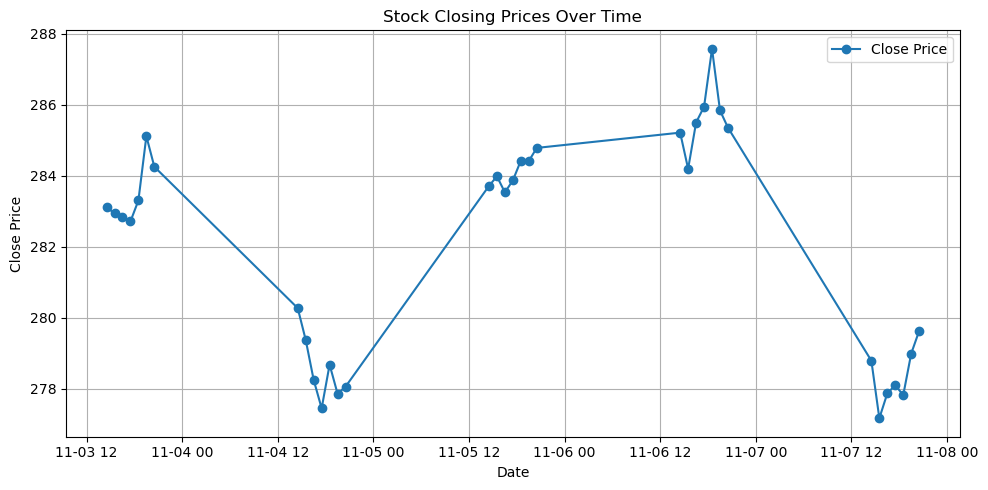

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(goog_close['Date'], goog_close['Close'], marker='o', label='Close Price')
plt.title('Stock Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

There seems to issues with timescales when market is closed.